# Crossdating tree-ring data with dplPy

A tour of dplPy's crossdating tools — the checks that confirm every ring is
assigned to its correct calendar year. We build a leave-one-out master
chronology and correlate each series against it, flag segments that don't match,
locate dating shifts, date a floating series, and produce a COFECHA-style report.

Uses the sample files in `../tests/data/rwl/`, so it runs as-is from the
`notebooks/` folder of the repository.

In [1]:
import dplpy as dpl
import matplotlib.pyplot as plt
import pandas as pd

dpl.__version__

'0.6.0'

In [2]:
RWL = "../tests/data/rwl/"   # sample files, relative to the notebooks/ folder

## 1. Data for crossdating

Read a collection and detrend it to ring-width indices (RWI) — crossdating works
on the detrended series.

ca533.rwl successfully extracted as rwl file with 34 series covering the period from 626 to 1983


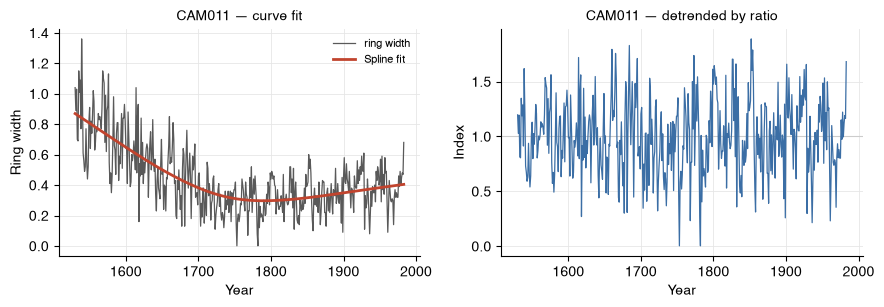

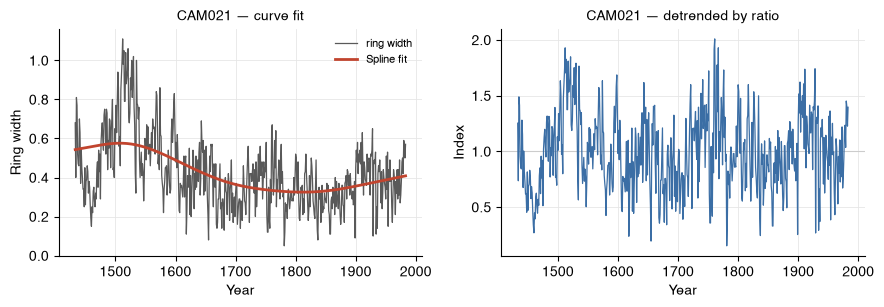

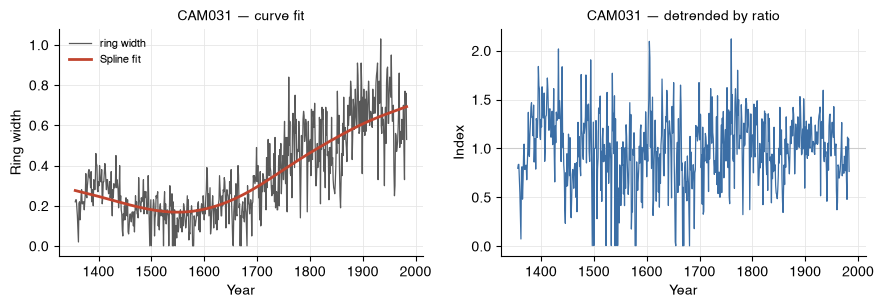

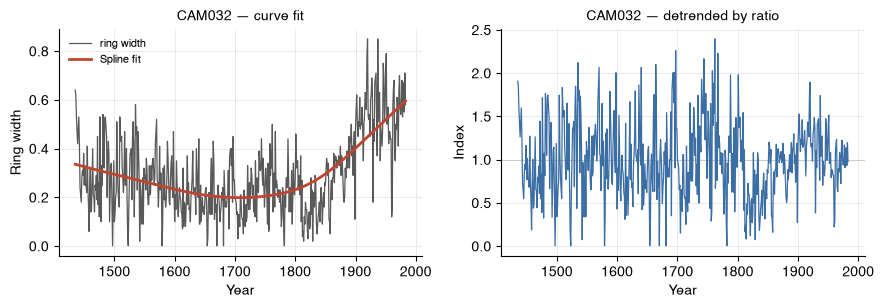

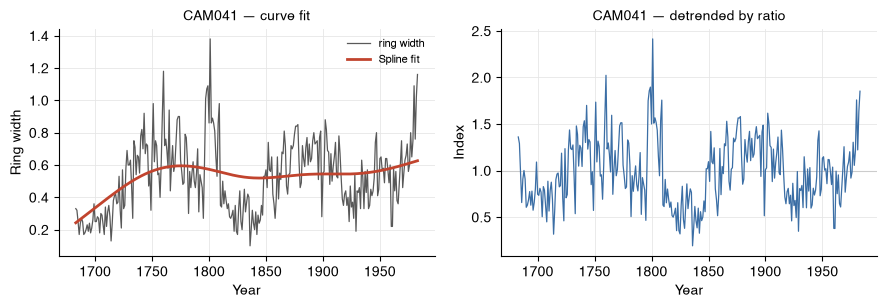

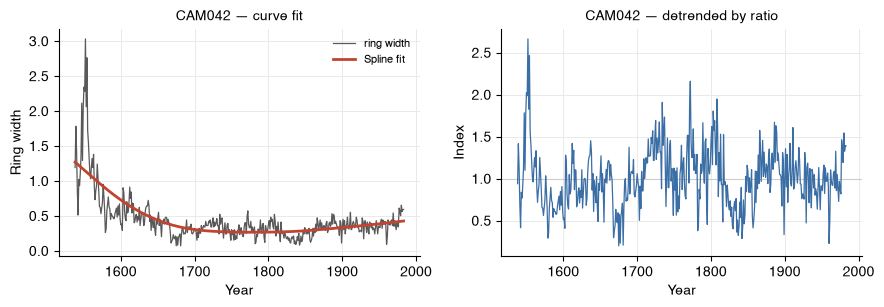

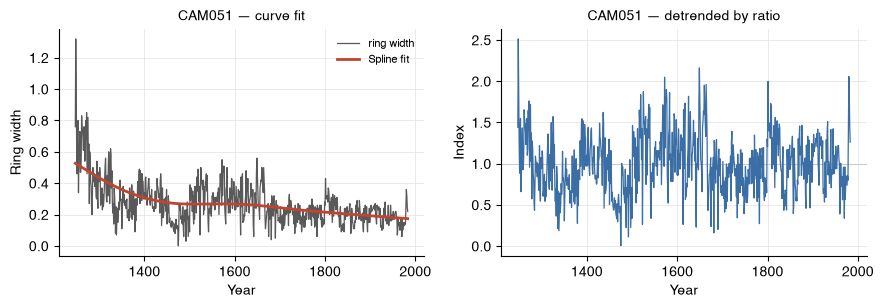

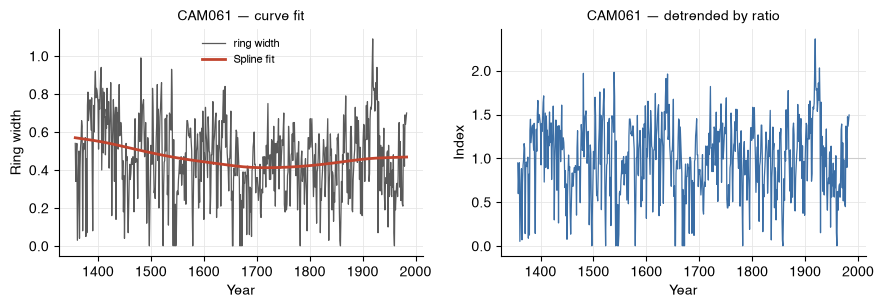

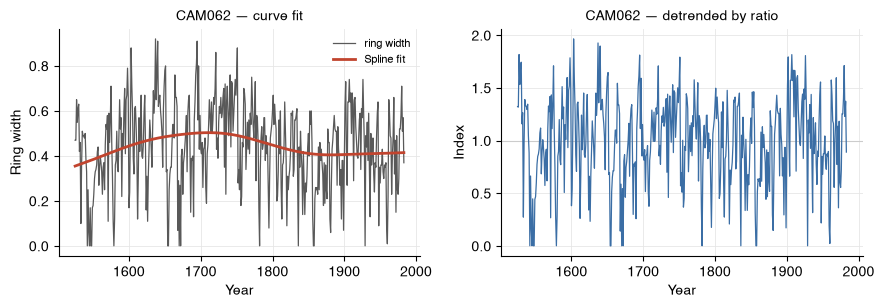

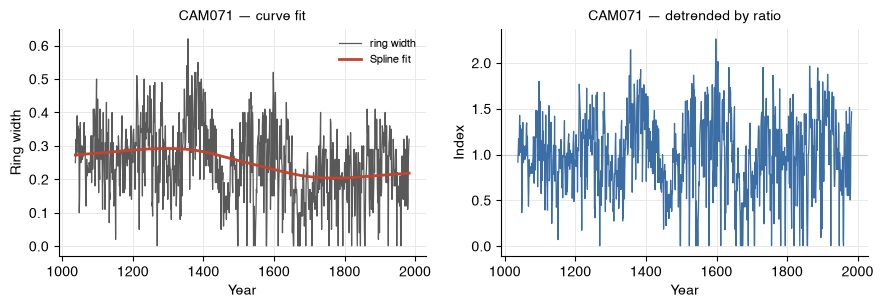

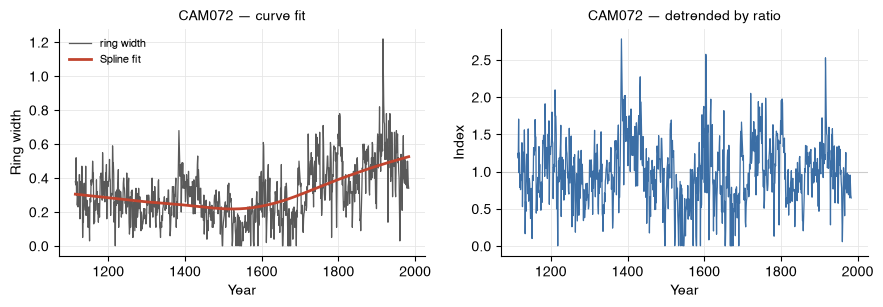

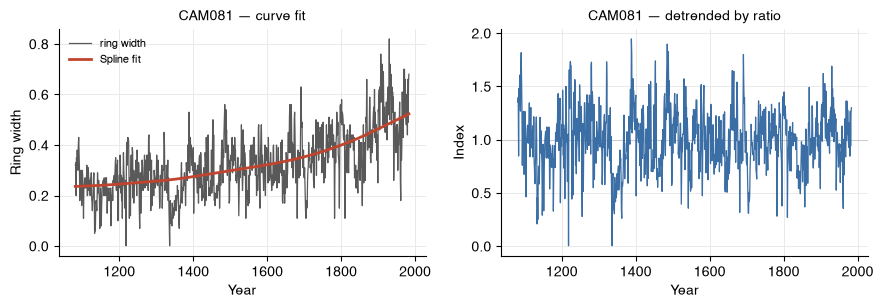

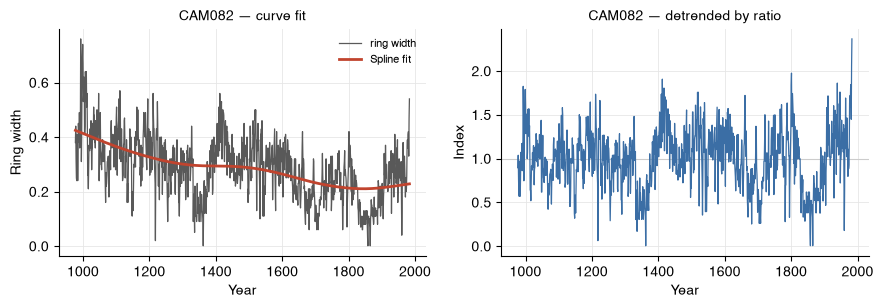

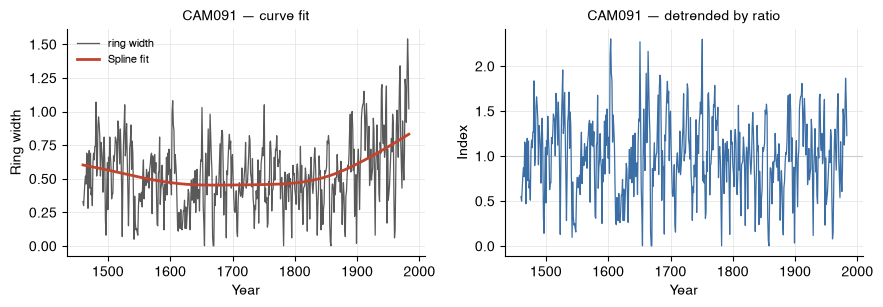

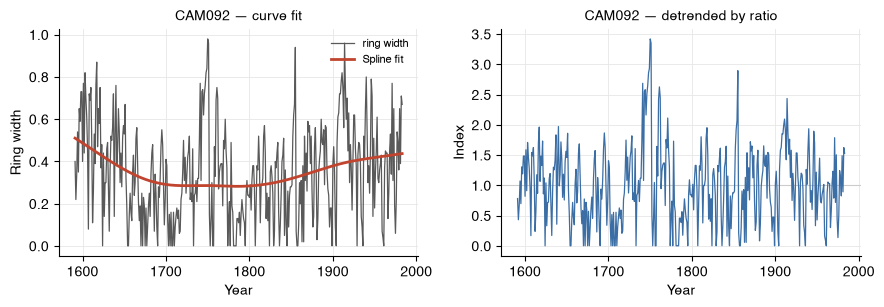

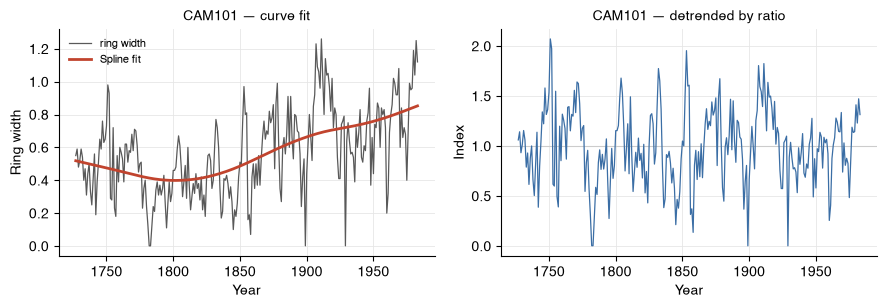

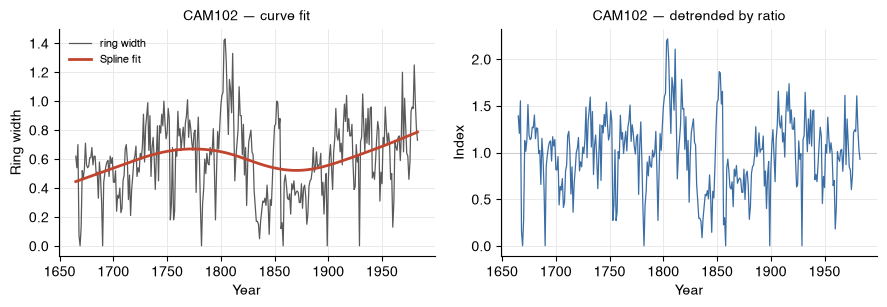

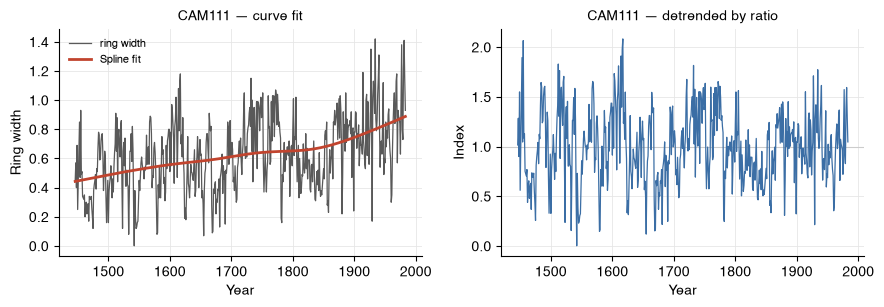

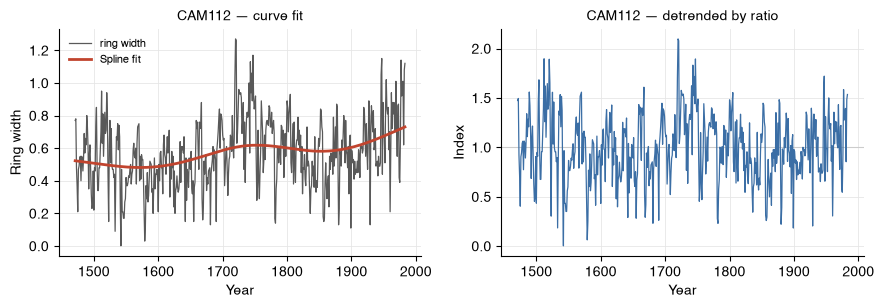

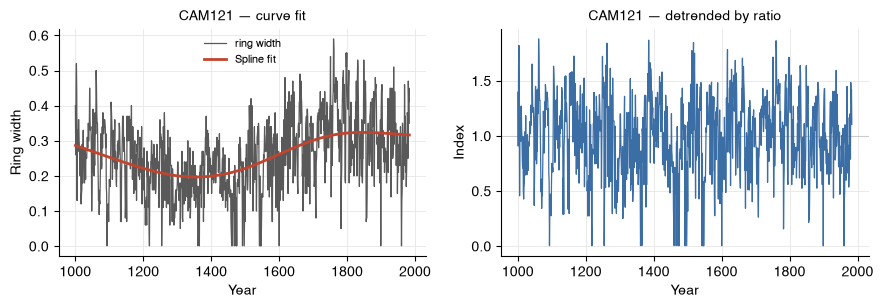

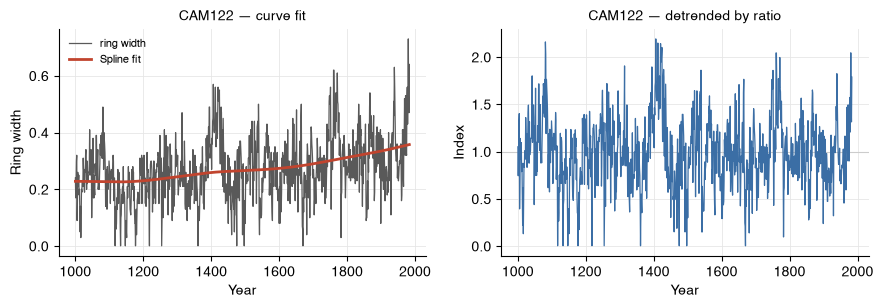

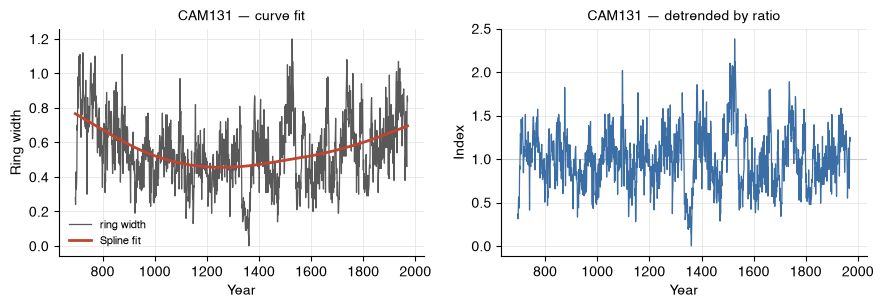

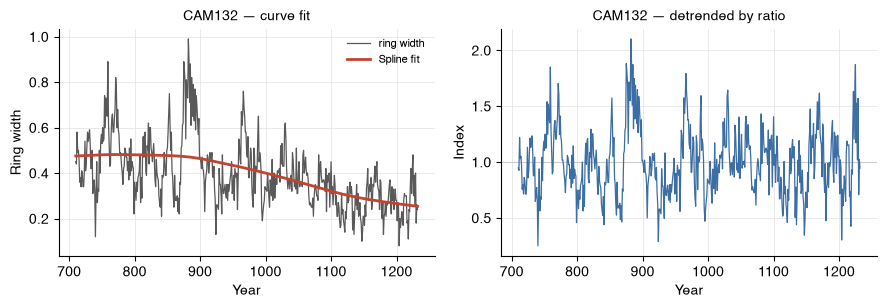

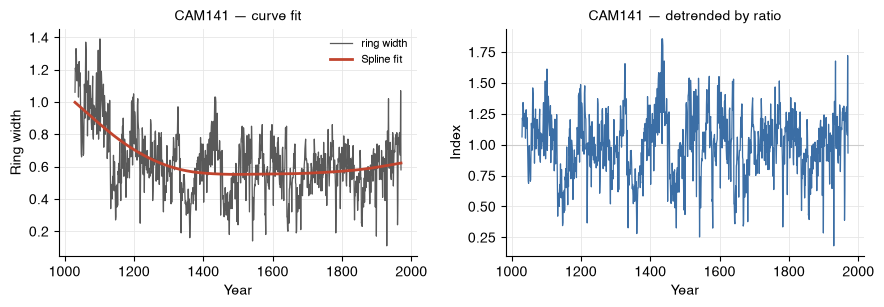

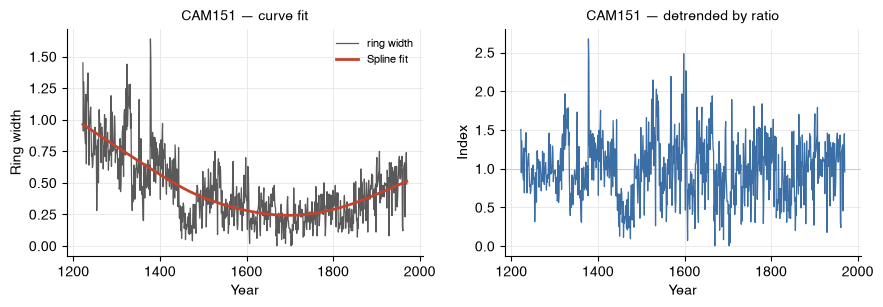

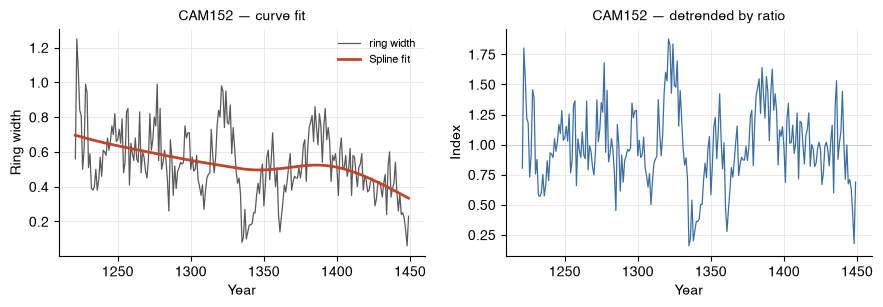

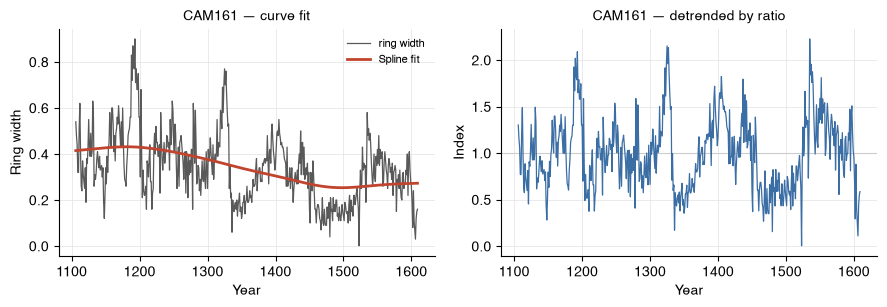

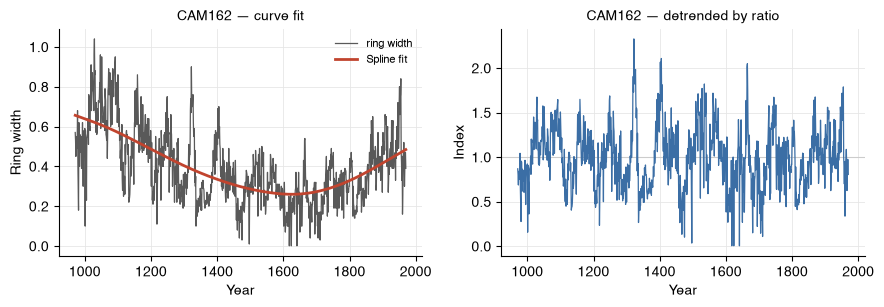

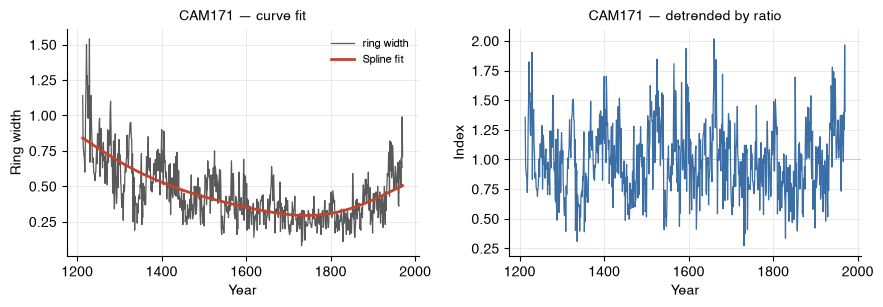

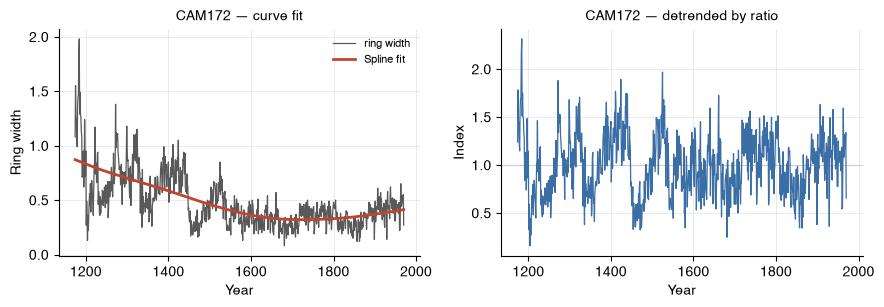

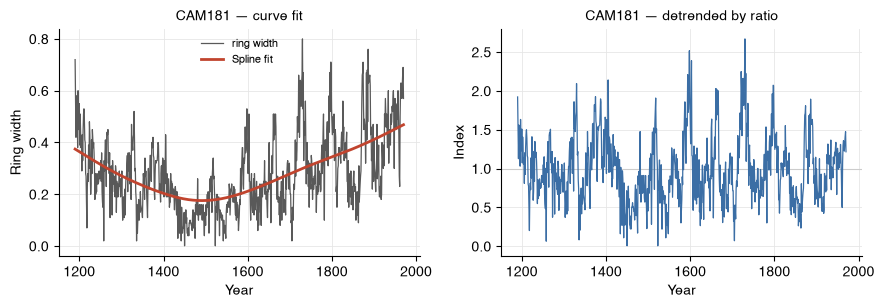

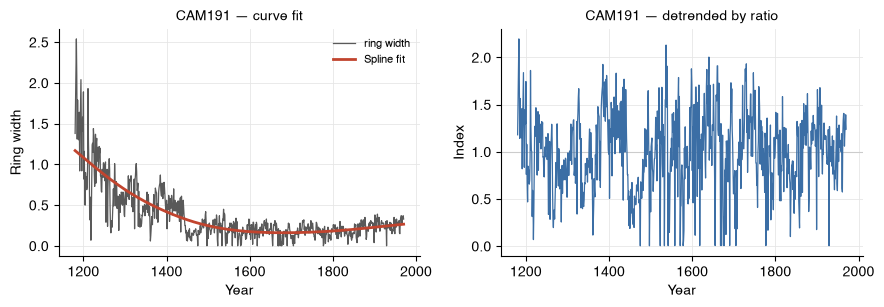

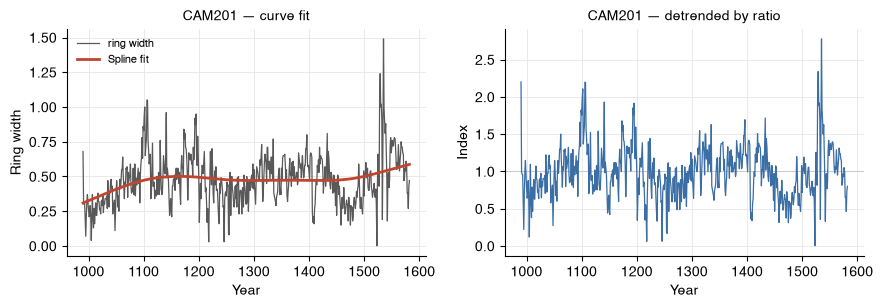

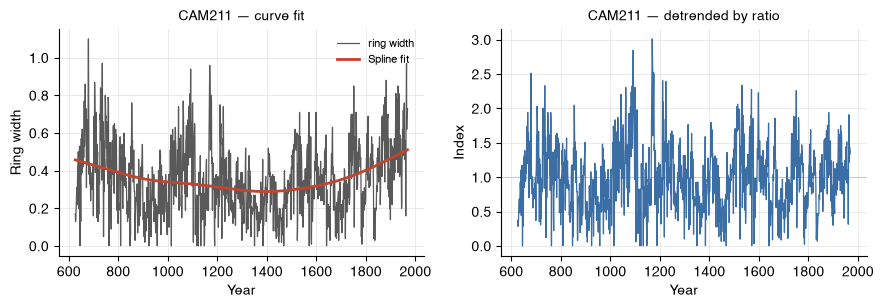

,CAM011,CAM021,CAM031,CAM032
Year,,,,
626,NaN,NaN,NaN,NaN
627,NaN,NaN,NaN,NaN
628,NaN,NaN,NaN,NaN
629,NaN,NaN,NaN,NaN
630,NaN,NaN,NaN,NaN


In [3]:
rwl = dpl.readers(RWL + "ca533.rwl")
rwi = dpl.detrend(rwl, fit="Spline")
rwi.iloc[:5, :4]

## 2. Mean interseries correlation

How strongly each series agrees with the master built from all the others (the
statistic COFECHA reports as the interseries correlation). This one takes the
**raw** ring widths — it normalizes internally.

In [4]:
mean_corr, ic = dpl.interseries_corr(rwl)
mean_corr                              # collection-wide mean interseries correlation

0.629

In [5]:
ic.head()                             # the per-series table

,interseries_corr,p_val
series,,
CAM011,0.526,2.552616e-32
CAM021,0.658,6.382256e-69
CAM031,0.528,2.265238e-45
CAM032,0.627,5.164840e-61
CAM041,0.489,1.187802e-19


## 3. Crossdating with `xdate`

Correlate each series against the leave-one-out master over overlapping segments.
Segments that fail are flagged **A** (not significant) or **B** (correlates
better at a non-zero lag — a possible dating shift). The flag report prints as it
runs; the full results come back in a dict.

In [6]:
res = dpl.xdate(rwi)
list(res.keys())

Flags for CAM011
  [B] correlates better at another lag ('best' = that lag):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1900-1949     +6   -0.05 -0.31  0.18 -0.17  0.04 -0.20 -0.16  0.09 -0.17  0.21  0.14 -0.08 -0.03  0.08  0.12 -0.06  0.31  0.20 -0.17  0.09 -0.05
      1925-1974     -8   -0.07 -0.28  0.29 -0.19  0.18 -0.20 -0.04 -0.00  0.04  0.08  0.27 -0.17 -0.10 -0.22  0.08  0.17  0.28 -0.09 -0.34  0.07      

Flags for CAM031
  [B] correlates better at another lag ('best' = that lag):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1775-1824     +8   -0.11  0.05 -0.10 -0.09 -0.11  0.09  0.15 -0.06 -0.07  0.07  0.29 -0.11  0.02 -0.12  0.02  0.01 -0.29 -0.10  0.36  0.05 -0.04

Flags for CAM051
  [B] correlates better at another lag ('best' = that lag):
      Segmen

['seg_corr', 'p_val', 'overall', 'avg_seg_corr', 'flags', 'bins', 'rwi']

In [ ]:
res["overall"]

## 4. The crossdating overview plot

Green = a series' extent, blue = a segment that dates well, red = a flagged
segment to inspect.

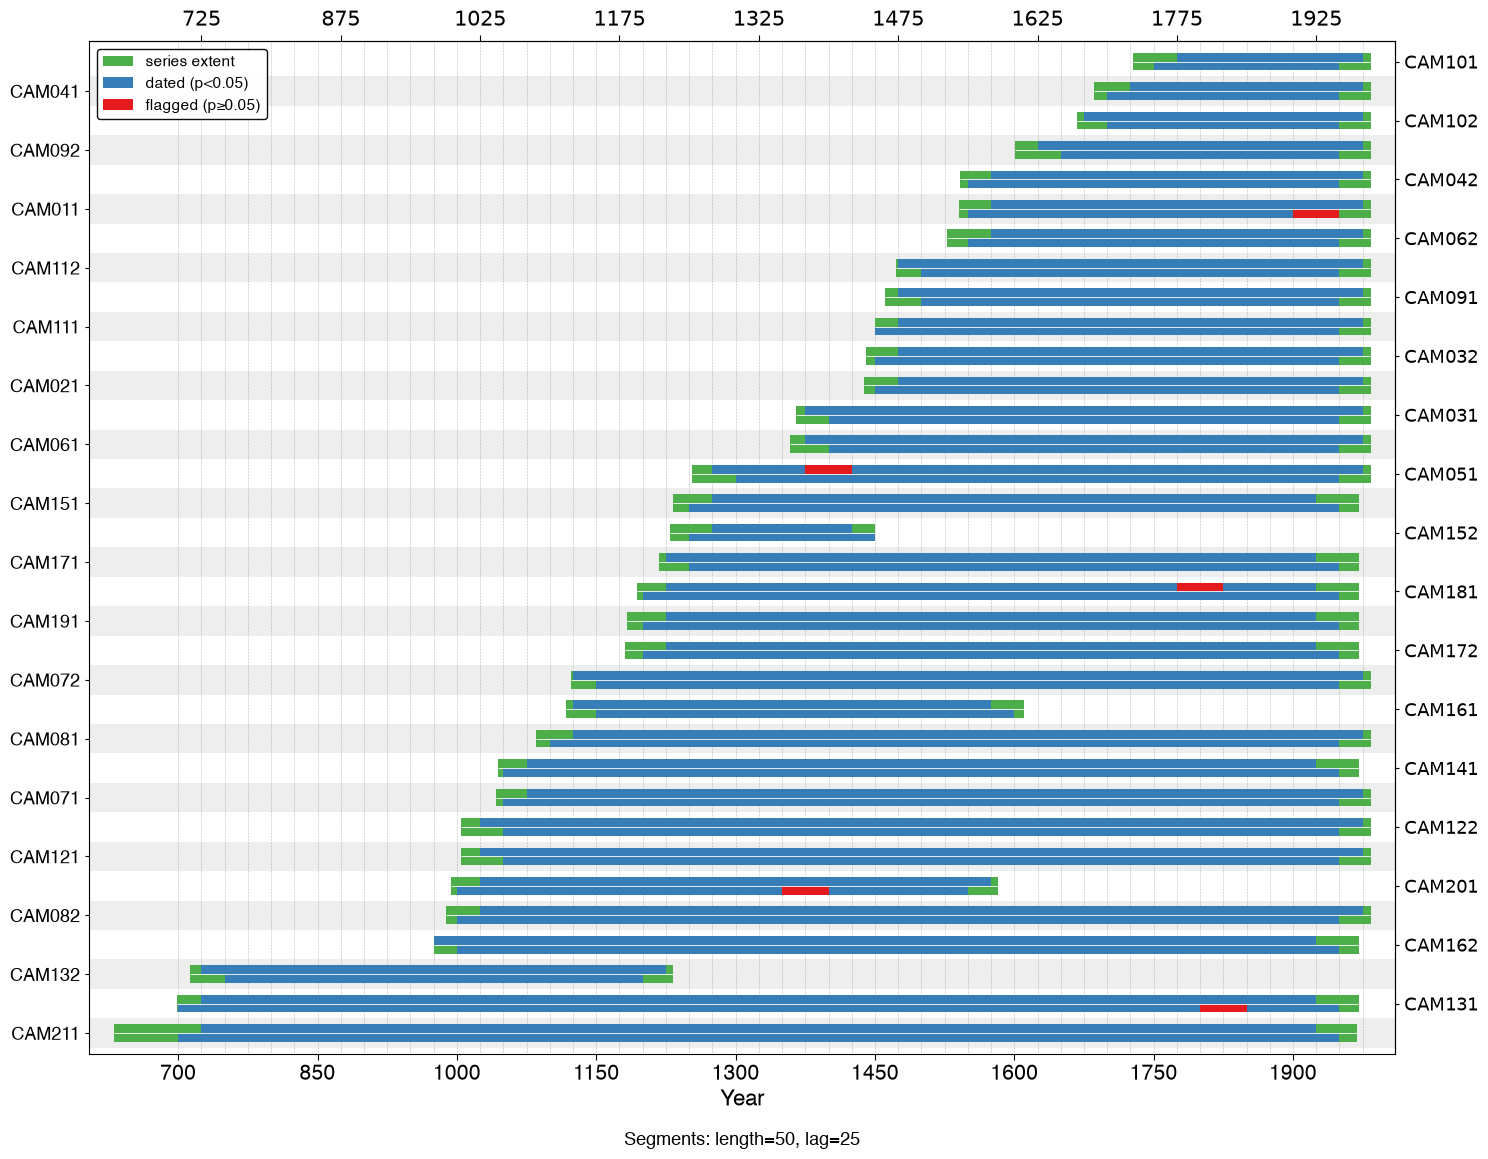

In [8]:
dpl.xdate_plot(rwi,p_val=0.05)
plt.show()

## 5. Detecting a dating error

Introduce a deliberate mistake — shift one series five years off its true dates —
and crossdating catches it: every segment flags, and the best correlation sits at
lag -5, the size of the error.

In [10]:
bad = rwi.copy()
col = bad["CAM041"].dropna()
bad["CAM041"] = pd.Series(col.values, index=col.index + 5).reindex(bad.index)

res_bad = dpl.xdate(bad)

Flags for CAM011
  [B] correlates better at another lag ('best' = that lag):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1900-1949     +6   -0.03 -0.30  0.20 -0.16  0.04 -0.20 -0.17  0.10 -0.14  0.21  0.14 -0.08 -0.04  0.08  0.12 -0.04  0.29  0.18 -0.16  0.04 -0.07
      1925-1974     -8   -0.06 -0.28  0.29 -0.17  0.18 -0.19 -0.05 -0.00  0.06  0.09  0.26 -0.19 -0.11 -0.21  0.06  0.19  0.28 -0.09 -0.35  0.06      

Flags for CAM031
  [B] correlates better at another lag ('best' = that lag):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1775-1824     +8   -0.12  0.06 -0.10 -0.11 -0.10  0.09  0.15 -0.05 -0.06  0.06  0.29 -0.10  0.02 -0.13  0.01  0.02 -0.30 -0.10  0.35  0.04 -0.06

Flags for CAM041
  [B] correlates better at another lag ('best' = that lag):
      Segmen

In [11]:
res_bad["flags"]["CAM041"]["B"][0]     # best lag = -5, the shift we introduced

{'segment': '1700-1749',
 'best_lag': -5,
 'best_corr': np.float64(0.41858343337334936),
 'lags': ['-0.04',
  ' 0.00',
  ' 0.20',
  '-0.05',
  '-0.12',
  ' 0.42',
  ' 0.03',
  ' 0.02',
  ' 0.24',
  ' 0.12',
  '-0.26',
  ' 0.19',
  ' 0.01',
  '-0.01',
  ' 0.11',
  ' 0.21',
  '-0.21',
  ' 0.01',
  ' 0.08',
  '-0.18',
  '-0.05']}

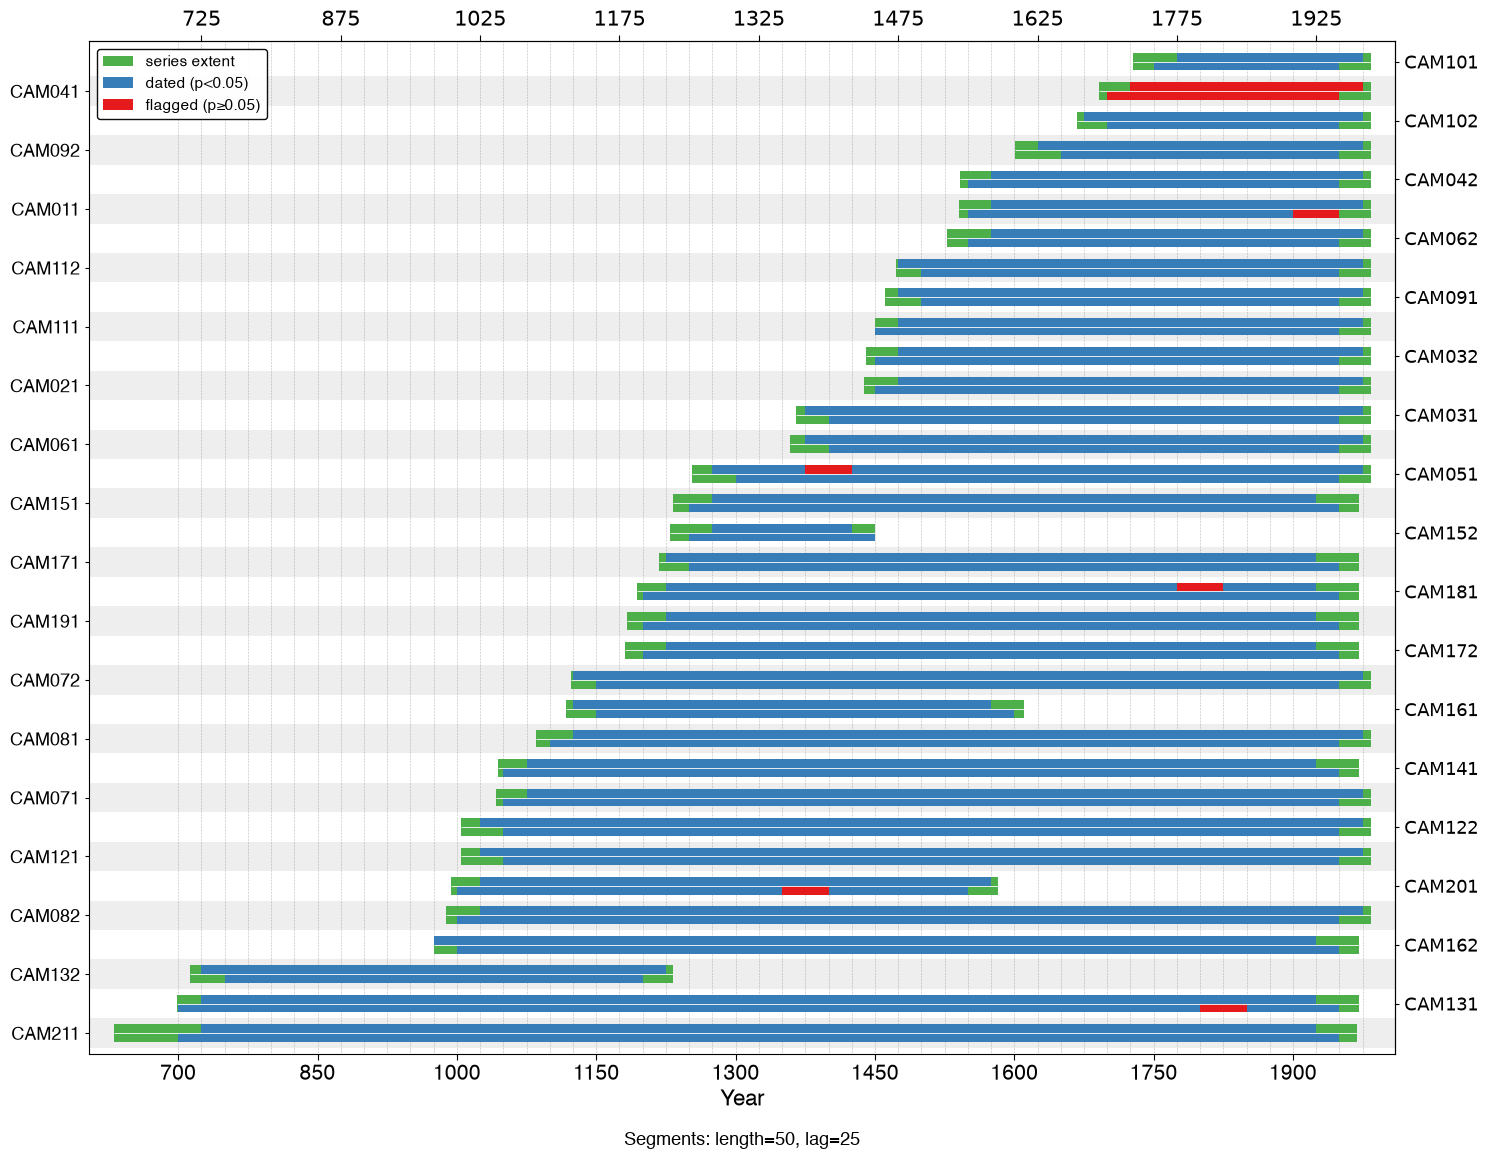

In [12]:
dpl.xdate_plot(bad)                    # CAM041 now reads red
plt.show()

## 6. Drilling into one series

`series_corr` examines a single series against the master: a moving correlation
and a per-segment lag panel. For the misdated series the peak sits off zero, at
the -5 shift.

NB: with series_x=True, positive lags indicate missing rings in the series


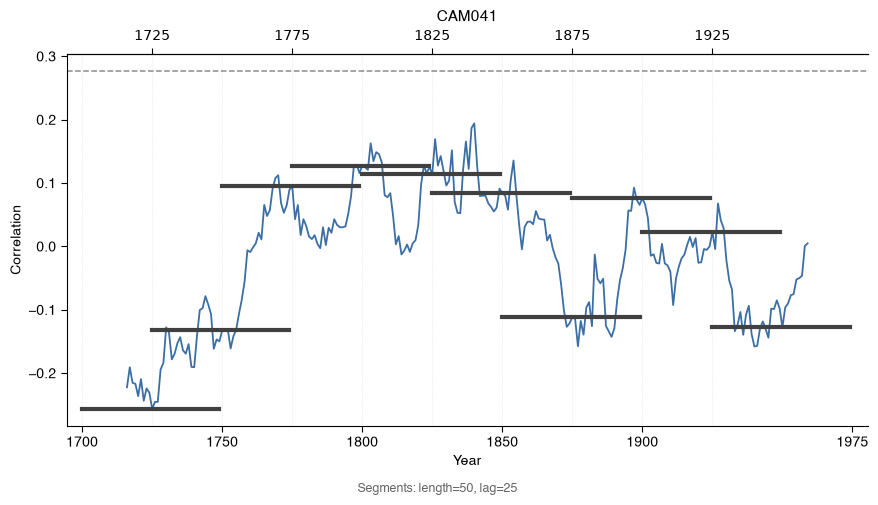

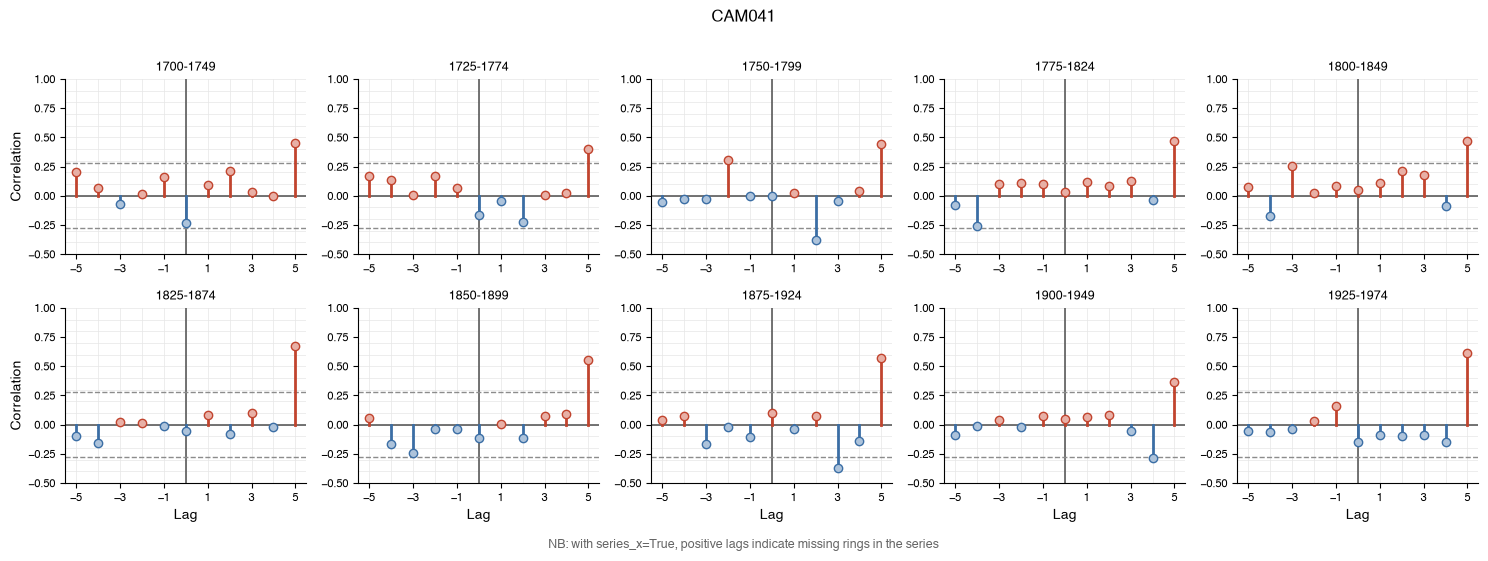

In [13]:
sc = dpl.series_corr(bad, "CAM041", make_plot=True)
plt.show()

## 7. Dating a floating series

Given a dated reference collection, `xdate_floater` finds the calendar placement
of an undated series. Here we take a series, discard its dates, and recover
them.

Reference master years: 631 to 1983 (1353)
Floating series length: 551 (transform 'pw' -> 543)
Minimum overlap for search: 50

Best match for 'CAM021': 1433 to 1983  (t = 20.32, r = 0.658, eff_df = 543, p_bonf = 1.00e-65, 1/p = >1 million, IF = >1000, overlap n = 543)


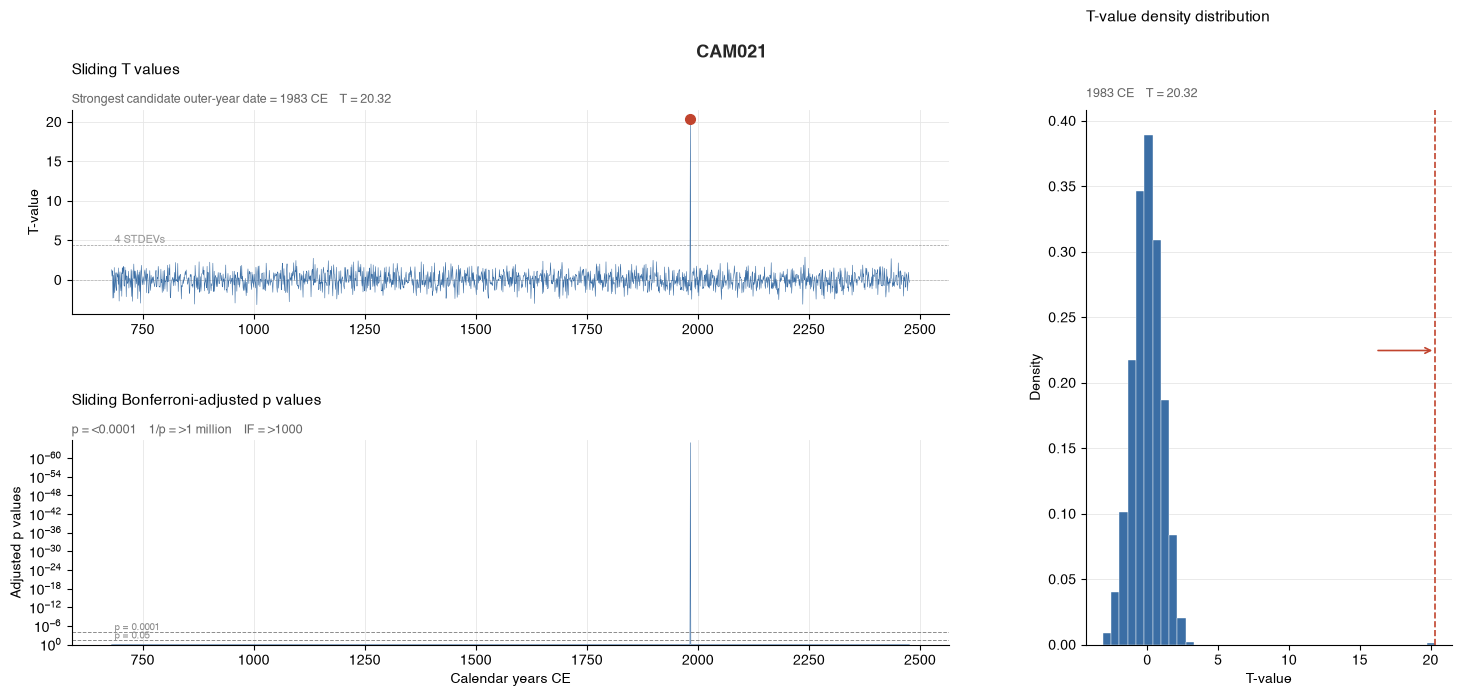

In [14]:
floating = rwl["CAM021"].dropna().values      # just the ring values, undated
reference = rwl.drop(columns=["CAM021"])

fl = dpl.xdate_floater(reference, floating, series_name="CAM021", make_plot=True)
plt.show()

In [15]:
fl["best"]                             # recovered span + crossdating statistics

{'min_year': 1433,
 'max_year': 1983,
 'r': 0.6578592569318609,
 't': 20.316709406536685,
 'eff_df': 542.9949488740576,
 'p_bonf': 1.003821237651682e-65,
 'one_over_p': 9.961933086207446e+64,
 'isolation_factor': 4.0618157572701726e+65,
 'n': 543}

## 8. COFECHA emulation

`preset="COFECHA"` reproduces the COFECHA program (a 32-year spline detrend, Burg
prewhitening, an arithmetic z-scored master, Pearson correlation, and COFECHA's
segment anchoring and critical value), returning its "possible problems" count.
Unlike the default path, the preset takes the **raw** ring widths and detrends
them itself — no need to call `detrend` first.

In [18]:
cof = dpl.xdate(rwl, preset="COFECHA")   # raw frame; the preset detrends internally
cof["n_problems"]

Flags for CAM011
  [A] not significant as dated ('best' = lag of highest correlation):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1900-1949     +0    0.03 -0.25  0.17 -0.04  0.08 -0.22 -0.23 -0.02 -0.20  0.07  0.31 -0.23 -0.04 -0.06 -0.00 -0.01  0.22  0.26 -0.14  0.08 -0.13
  [B] correlates better at another lag ('best' = that lag):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1934-1983     -1   -0.02 -0.08  0.14  0.08  0.03 -0.15 -0.06 -0.04 -0.03  0.27  0.17                                                            

Flags for CAM031
  [A] not significant as dated ('best' = lag of highest correlation):
      Segment     best     -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0    +1    +2    +3    +4    +5    +6    +7    +8    +9   +10
      1800

17

## 9. Prewhitening under the hood

Crossdating prewhitens each series with an autoregressive model first, to compare
the high-frequency signal. `autoreg` exposes that fit directly.

In [ ]:
dpl.autoreg(rwl["CAM011"].dropna())    # selected AR order and coefficients

## 10. A batch QA report

`xdate_report` reads, detrends, crossdates, and produces a COFECHA-style report
per file — built for batch QA. `output=` controls where it goes: `"screen"`
prints it here, `"file"` writes a `.txt`, and `"both"` (the default) does both.

In [21]:
rep = dpl.xdate_report(RWL + "ca533.rwl", output="both",preset="COFECHA")

ca533.rwl successfully extracted as rwl file with 34 series covering the period from 626 to 1983

COFECHA-style output, reproduced with dplPy 0.6.0 preset="COFECHA" on 11Sep26


      Measurement file name  : ca533.rwl
      Beginning year         : 626
      Ending year            : 1983

      Series intercorrelation: .669
      Avg mean sensitivity   : .316
      Avg standard deviation : .188
      Avg autocorrelation    : .720
      Number dated series    : 34
      Segment length tested  : 50

      Number problem segments: 20
      Pct problem segments   : 2.16


 PART 5:  CORRELATION OF SERIES BY SEGMENTS: 
-----------------------------------------------------------------------------------------------------------------------------------
Correlations of  50-year dated segments, lagged  25 years
Flags:  A = correlation under .3281 but highest as dated;  B = correlation higher at other than dated position
        critical value .3281 for the 50-year window, from pcrit = 0.01, one t